<a href="https://colab.research.google.com/github/kritisrivastava676-wq/FUTURE_DS_02/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

# This creates an upload button right in your notebook!
uploaded = files.upload()

Saving archive.zip to archive.zip


Unzipping data...
Found file: WA_Fn-UseC_-Telco-Customer-Churn.csv. Generating Report...



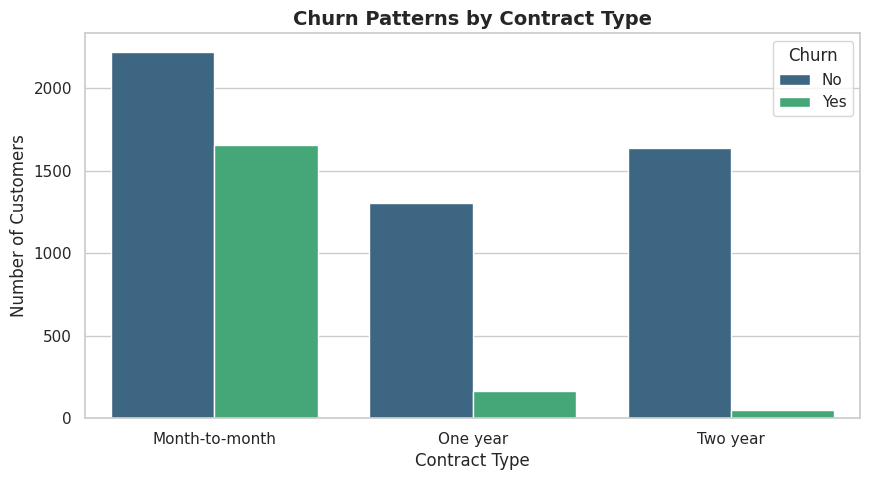

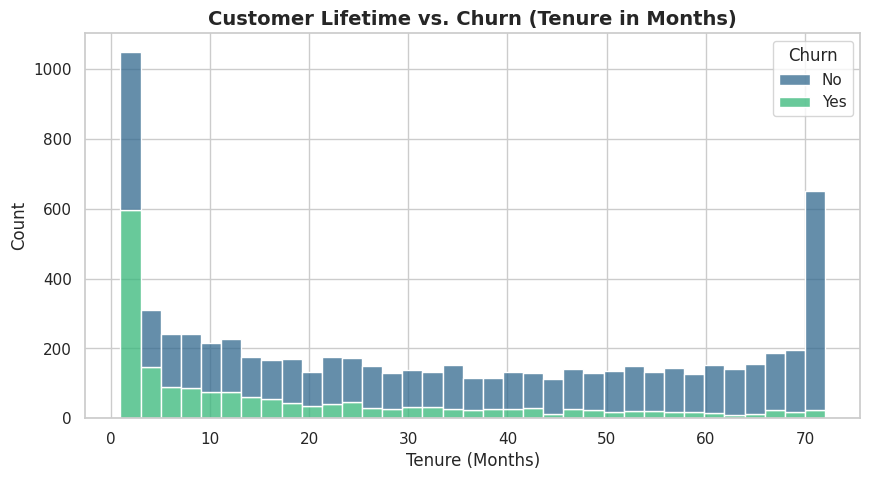

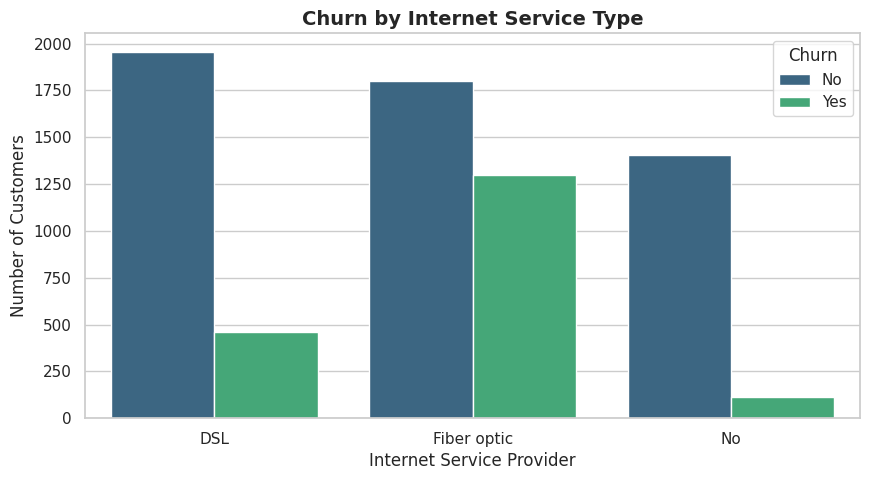

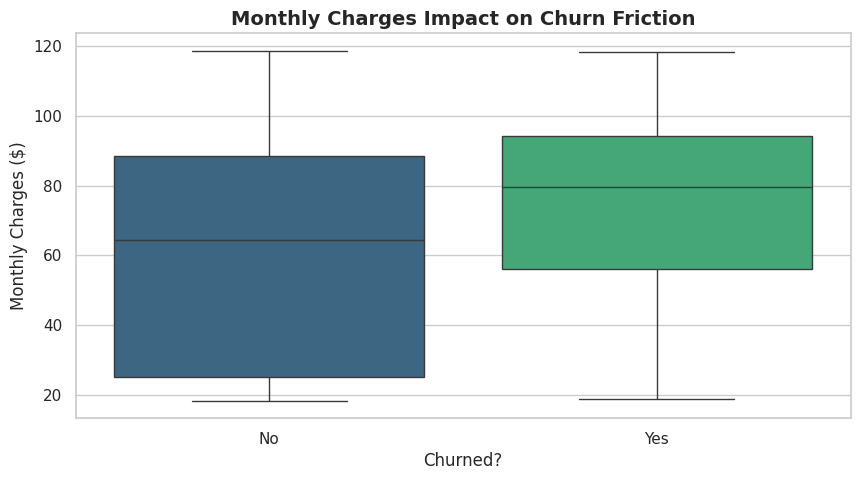

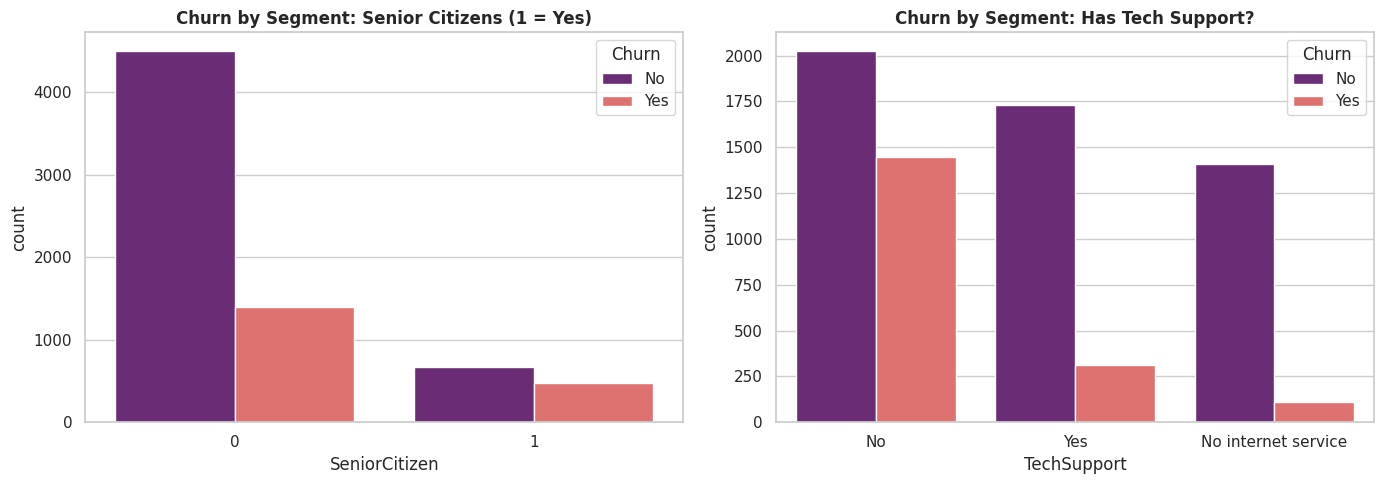

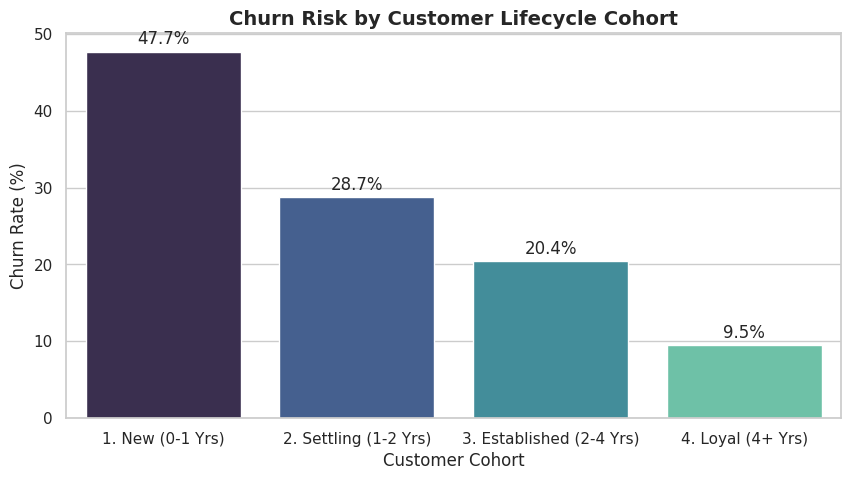


##################################################
====== EXECUTIVE SUMMARY FOR STAKEHOLDERS ======
Total Active Customers Analyzed : 7,032
Overall Corporate Churn Rate    : 26.58%
------------------------------------------------
Total Monthly Revenue           : $455,661.00
Monthly Revenue Lost to Churn   : $139,130.85
Percentage of Revenue Bleed     : 30.53%
##################################################


In [2]:
import warnings
warnings.filterwarnings('ignore')

import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. UNZIP AND LOAD DATA
# ==========================================
print("Unzipping data...")
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall()

# Find the extracted CSV file automatically
csv_file = [f for f in os.listdir() if f.endswith('.csv')][0]
print(f"Found file: {csv_file}. Generating Report...\n")

df = pd.read_csv(csv_file)

# ==========================================
# 2. DATA CLEANING & PREPARATION
# ==========================================
# Handle blank spaces in TotalCharges and convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# Create a numeric label for calculation (1 = Churned, 0 = Retained)
df['Churn_Label'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ==========================================
# 3. CORE VISUALIZATIONS
# ==========================================
sns.set_theme(style="whitegrid")

# Chart 1: Churn by Contract Type
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn Patterns by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

# Chart 2: Customer Lifetime Trend
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='viridis', bins=35)
plt.title('Customer Lifetime vs. Churn (Tenure in Months)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

# Chart 3: Churn by Internet Service
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='viridis')
plt.title('Churn by Internet Service Type', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service Provider')
plt.ylabel('Number of Customers')
plt.show()

# Chart 4: Monthly Charges Impact
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='viridis')
plt.title('Monthly Charges Impact on Churn Friction', fontsize=14, fontweight='bold')
plt.xlabel('Churned?')
plt.ylabel('Monthly Charges ($)')
plt.show()

# ==========================================
# 4. BONUS UPGRADE: SEGMENTS
# ==========================================
plt.figure(figsize=(14, 5))

# Subplot A: Senior Citizens
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette='magma')
plt.title('Churn by Segment: Senior Citizens (1 = Yes)', fontweight='bold')

# Subplot B: Tech Support
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='TechSupport', hue='Churn', palette='magma')
plt.title('Churn by Segment: Has Tech Support?', fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 5. ADVANCED UPGRADE: TENURE COHORT ANALYSIS
# ==========================================
def assign_cohort(tenure):
    if tenure <= 12:
        return '1. New (0-1 Yrs)'
    elif tenure <= 24:
        return '2. Settling (1-2 Yrs)'
    elif tenure <= 48:
        return '3. Established (2-4 Yrs)'
    else:
        return '4. Loyal (4+ Yrs)'

df['Tenure_Cohort'] = df['tenure'].apply(assign_cohort)
cohort_churn = df.groupby('Tenure_Cohort')['Churn_Label'].mean() * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=cohort_churn.index, y=cohort_churn.values, palette='mako')
plt.title('Churn Risk by Customer Lifecycle Cohort', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Customer Cohort')

# Add the percentages on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()

# ==========================================
# 6. FINAL EXECUTIVE SUMMARY METRICS
# ==========================================
total_cust = len(df)
churn_rate = df['Churn_Label'].mean() * 100
revenue_lost = df[df['Churn_Label'] == 1]['MonthlyCharges'].sum()
total_revenue = df['MonthlyCharges'].sum()
pct_revenue_lost = (revenue_lost / total_revenue) * 100

print("\n" + "#"*50)
print("====== EXECUTIVE SUMMARY FOR STAKEHOLDERS ======")
print(f"Total Active Customers Analyzed : {total_cust:,}")
print(f"Overall Corporate Churn Rate    : {churn_rate:.2f}%")
print("------------------------------------------------")
print(f"Total Monthly Revenue           : ${total_revenue:,.2f}")
print(f"Monthly Revenue Lost to Churn   : ${revenue_lost:,.2f}")
print(f"Percentage of Revenue Bleed     : {pct_revenue_lost:.2f}%")
print("#"*50)